# Generar Corpus en iniciativas legíslativas sobre LEY y SALUD


## NLP para IL - proyectos de ley 
#### Preprocesamiento de textos

La normalización de texto es un proceso que transforma el texto a un formato estándar. Es un paso previo importante en el procesamiento del lenguaje natural:

Esto fue realizado en script:

* ✅ Eliminar  carácteres como puntos, comas, comillas, espacios, brackets, etc.
* ✅ Convertir los números a su equivalente a palabras
* ✅ Convertir a minúsculas
* ✅ Lematizar
* ✅ Remover stopwords (opcional)

Esto se analizará en esta notebook  
* ✅ Identificar palabras asociadas a dominio de las leyess
* ✅ Filtrar palabras asociadas a dominio

Tokenization: Tarea de dividir grandes cadenas de texto solo y exclusivamente en palabras.

Se guardará aqué el corpus IL 

In [1]:
# Importar librerias
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

In [2]:
### CONFIGURACION
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

## 1 - Recolección de textos preprocesados en script

In [3]:
with open(RESULTADOS_DIR + '/muerte_subita/pms_texto_df_2009_2024_POC.pkl', 'rb') as file: 
    texto_df = pickle.load(file) # texto_normalizado_2009_2024_df

In [4]:
texto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   Proyecto.ID                         9 non-null      object  
 1   Título                              9 non-null      category
 2   Título procesado                    9 non-null      object  
 3   Título normalizado                  9 non-null      object  
 4   Cant_token                          9 non-null      int64   
 5   Cant_token_normalizado              9 non-null      int64   
 6   Proyecto_girado_a_comisiones_SALUD  9 non-null      float64 
 7   Proyecto_SALUD                      9 non-null      float64 
 8   Resultado                           9 non-null      category
 9   Max_Orden                           9 non-null      int64   
 10  Tiene_antecedente_por_titulo_proy   9 non-null      bool    
 11  Periodo                             

In [5]:
texto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,9,9,HCDN266842,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,9,8,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,9,7,programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita regimen capacitacion en reanimacion cardiopulmonar,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,9,6,programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,9.0,NaN,NaN,NaN,24.333333,9.394147,14.0,20.0,24.0,24.0,43.0
Cant_token_normalizado,9.0,NaN,NaN,NaN,14.333333,3.968627,9.0,13.0,15.0,15.0,20.0
Proyecto_girado_a_comisiones_SALUD,9.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Proyecto_SALUD,9.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Resultado,9,1,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,9.0,NaN,NaN,NaN,2.888889,0.927961,2.0,2.0,3.0,4.0,4.0


## 2 -Limpieza y preparación de los datos (dominio de datos) 

In [6]:
# Librerias para texto
import re
import nltk
import spacy
from spacy.lang.es.stop_words import STOP_WORDS

# https://pypi.org/project/textacy/
import textacy
import textacy.preprocessing as tprep
from src.nlp import limpiar_texto_legislativo

In [7]:
texto_df.head(4)

Proyecto.ID  \
0  HCDN266842   
1  HCDN255602   
2  HCDN243571   
3  HCDN238109   

                                                                                                                                                                                                                                                                         Título  \
0               PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.   
1                                                                                                    PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.   
2  MUERTE SUBITA. SISTEMA DE PREVENCION INTEGRAL - LEY 27159 -. MODIFICACIONES SOBRE LA COLOCACION DE DISPOSITIVOS DEA EN ESTABLECIMIENTOS EDUCATIVOS PUBLICOS Y PRIVADOS, ESTABLECIMIENTOS DEPORTIVOS, GIMNASIOS, CLUBES Y SERVICIOS DE ALOJAMIENTO CON SECTORES DEPORTIVOS .    
3                                                                                                    PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.   

                                                                                                                                                                                                                                                    Título procesado  \
0             proteccion del embarazo y del recien nacido ley numero muerte subita sistema de prevencion integral ley numero modificaciones sobre instruccion basica en rcp en el estado nacional y para progenitores de ninos recien nacidos en situacion de riesgo   
1                                                                                            programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita regimen capacitacion en reanimacion cardiopulmonar   
2  muerte subita sistema de prevencion integral ley numero modificaciones sobre la colocacion de dispositivos dea en establecimientos educativos publicos y privados establecimientos deportivos gimnasios clubes y servicios de alojamiento con sectores deportivos   
3                                                                                            programa de difusion e informacion a padres y miembros de la comunidad escolar destinado a prevenir la muerte subita regimen capacitacion en reanimacion cardiopulmonar   

                                                                                                                                                                               Título normalizado  \
0                                proteccion embarazo recien nacido ley muerte subitar sistema prevencion integral  instruccion basico rcp nacional progenitor nino recien nacido situacion riesgo   
1                                                 programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar   
2  muerte subitar sistema prevencion integral  colocacion dispositivo dea establecimiento educativo publico privado establecimiento deportivo gimnasio club servicio alojamiento sector deportivo   
3                                                 programa difusion informacion padre miembro comunidad escolar destinado prevenir muerte subitar regimen capacitacion reanimacion cardiopulmonar   

   Cant_token  Cant_token_normalizado  Proyecto_girado_a_comisiones_SALUD  \
0          43                      20                                 1.0   
1          24                      15                                 1.0   
2 

Los textos de proyecto presentan entre 3 y 13384 caracteres.

<Axes: >

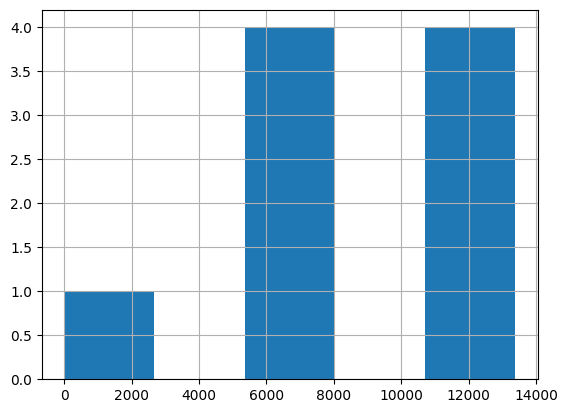

In [8]:
texto_df['texto_proyecto'].str.len().hist(bins=5)

In [9]:
texto_df['texto_proyecto'].str.len().describe()

count        9.000000
mean      8617.000000
std       3874.598334
min          0.000000
25%       7528.000000
50%       7962.000000
75%      11239.000000
max      13384.000000
Name: texto_proyecto, dtype: float64

Los textos de proyectos presentan en promedio 1330 palabras, min 0 palabras max 2078 palabras.

<Axes: >

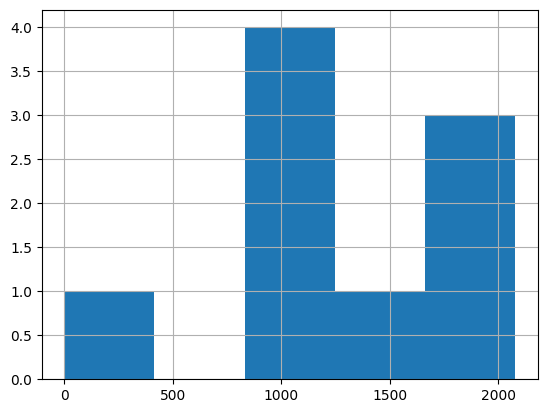

In [10]:
texto_df['texto_proyecto'].str.split().map(lambda x: len(x)).hist(bins='auto')

In [11]:
texto_df['texto_proyecto'].str.split().map(lambda x: len(x)).describe()

count       9.000000
mean     1330.222222
std       590.866478
min         0.000000
25%      1184.000000
50%      1243.000000
75%      1715.000000
max      2078.000000
Name: texto_proyecto, dtype: float64

In [12]:
texto_df['control_vacio'] = texto_df['texto_proyecto'].str.split().map(lambda x: len(x))

In [13]:
texto_df[texto_df['control_vacio']==0]

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_normalizado,Proyecto_girado_a_comisiones_SALUD,Proyecto_SALUD,Resultado,Max_Orden,Tiene_antecedente_por_titulo_proy,Periodo,Año,Tokens,metadata.expediente diputados,Cant_pag,texto_proyecto,proyecto_id,control_vacio
0,HCDN266842,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,proteccion del embarazo y del recien nacido ley numero muerte subita sistema de prevencion integral ley numero modificaciones sobre instruccion basica en rcp en el estado nacional y para progenitores de ninos recien nacidos en situacion de riesgo,proteccion embarazo recien nacido ley muerte subitar sistema prevencion integral instruccion basico rcp nacional progenitor nino recien nacido situacion riesgo,43,20,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,2,False,141.0,2023,"[proteccion, embarazo, recien, nacido, ley, muerte, subitar, sistema, prevencion, integral, instruccion, basico, rcp, nacional, progenitor, nino, recien, nacido, situacion, riesgo]",1031-d-2023,4.0,,HCDN266842,0


### Normalizando control

In [14]:
# abrir
with open(RESULTADOS_DIR + '/muerte_subita/texto_normalizado_202505101420_df.pkl', 'rb') as file: 
    texto_limpio_df = pickle.load(file)

In [15]:
texto_limpio_df.shape

(9, 4)

In [16]:
texto_limpio_df.columns

Index(['Proyecto.ID', 'texto_proyecto', 'texto_proyecto procesado',
       'texto_proyecto normalizado'],
      dtype='object')

**Controlando errores: ¿títulos vacios?**

In [17]:
texto_limpio_df[texto_limpio_df['texto_proyecto procesado']==" "] # Contiene la limpieza básica 

,Proyecto.ID,texto_proyecto,texto_proyecto procesado,texto_proyecto normalizado


In [18]:
texto_limpio_df[texto_limpio_df['texto_proyecto normalizado']==" "].shape

(0, 4)

**Validando Normalización**

In [19]:
# Chequeamos el proceso normalizado
import spacy
from spacy.lang.es.stop_words import STOP_WORDS
from src.nlp import limpiar_texto_legislativo


MODELO_NLP = spacy.load("es_core_news_md")
texto_orig = "GESTACION POR SUSTITUCION. REGIMEN. MODIFICACION DE LOS CODIGOS CIVIL Y COMERCIAL DE LA NACION Y PENAL DE LA NACION"
#texto_orig = texto_df[texto_df['texto_proyecto normalizado']==""]['Título'].values[0]
texto = limpiar_texto_legislativo.limpiar_texto_basico(texto_orig)

In [20]:
doc = MODELO_NLP(texto)
etiquetas_permitidas=['NOUN', 'ADJ', 'VERB', 'ADV']
minimo_caracteres = 1
for token in doc:
    print(token,token.pos_,token.lemma_)
    if token.lemma_ not in ['-PRON-']:
        token_lem = token.lemma_
    else:
        token_lem = ""
    if len(token_lem.strip()) > 0:
        if not (token_lem in STOP_WORDS):
            if len(token_lem) > minimo_caracteres:
                print("********") # token_lem

gestacion PROPN gestacion
********
por ADP por
sustitucion PROPN sustitucion
********
regimen PROPN regimen
********
modificacion PROPN modificacion
********
de ADP de
los DET el
codigos PROPN codigos
********
civil ADJ civil
********
y CCONJ y
comercial ADJ comercial
********
de ADP de
la DET el
nacion PROPN nacion
********
y CCONJ y
penal PROPN penal
********
de ADP de
la DET el
nacion PROPN nacion
********


#### Reducción de ruido en términos genéricos

Si ciertos n-gramas son muy frecuentes en todos los textos y no aportan información (ej. "en el año"), eliminarlos ayuda a que los embeddings reflejen conceptos más específicos del dominio.

Un n-grama es una secuencia de n elementos consecutivos de un texto o discurso. Los elementos pueden ser palabras, números, símbolos, fonemas, sílabas, letras, o pares de bases. 


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear bigramas y trigramas
vectorizer = CountVectorizer(ngram_range=(2,5), min_df=1) # Para n-gramas raros , si consideramos min_df = 1, p90=4
X = vectorizer.fit_transform(texto_limpio_df["texto_proyecto normalizado"])
n_gramas = vectorizer.get_feature_names_out()
frecuencias = X.sum(axis=0).A1
df_ngrams = pd.DataFrame({'ngram': n_gramas, 'frecuencia': frecuencias})
df_ngrams = df_ngrams.sort_values(by='frecuencia', ascending=False)

In [22]:
df_ngrams.describe() # Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1


,frecuencia
count,12328.000000
mean,1.804672
std,1.315909
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,62.000000


<Axes: >

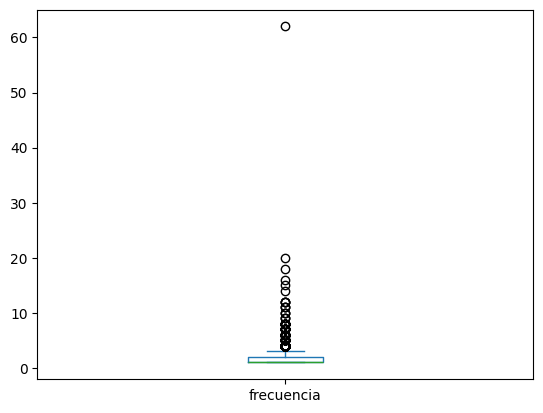

In [23]:
df_ngrams.plot.box()

In [24]:
umbral = df_ngrams['frecuencia'].quantile(0.95) # Eliminar n-gramas muy frecuentes (por encima del percentil 95)?

umbral

4.0

In [ ]:
# Mostrar top 50
print(df_ngrams.head(50))

# Visualizar
plt.figure(figsize=(12,6))
sns.barplot(data=df_ngrams.head(20), x='frecuencia', y='ngram', palette='viridis')
plt.title("Top 20 n-gramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("n-grama")
plt.tight_layout()
plt.show()

In [25]:
df_ngrams.head(12)

,ngram,frecuencia
7894,muerte subitar,62
8208,nino adolescente,20
142,actividad fisico,18
5457,examen fisico,16
3934,desfibrilador automatico,15
32,acceso publico,14
10169,publico privado,12
7672,ministerio salud,12
9834,programa prevencion,12
8712,paro cardiaco,12


In [26]:
df_ngrams = df_ngrams.head(1)
df_ngrams["n"] = df_ngrams['ngram'].str.split().map(lambda x: len(x))
df_ngrams = df_ngrams.sort_values("n", ascending = False)
df_ngrams


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17172\2629332765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ngrams["n"] = df_ngrams['ngram'].str.split().map(lambda x: len(x))


,ngram,frecuencia,n
7894,muerte subitar,62,2


In [27]:
df_ngrams['ngram'].unique()

array(['muerte subitar'], dtype=object)

Se eliminan por dominio de datos:['muerte subitar']

In [28]:
ngramas_a_eliminar = list(df_ngrams['ngram'].values) # Eliminar los top  12
# Crear un solo patrón con regex
patron = r'\b(' + '|'.join(map(re.escape, ngramas_a_eliminar)) + r')\b'
patron

'\\b(muerte\\ subitar)\\b'

In [29]:
texto_limpio_df['texto_proyecto normalizado'] = texto_limpio_df['texto_proyecto normalizado'].str.replace(patron, '', regex=True)

In [30]:
texto_limpio_df[texto_limpio_df['texto_proyecto normalizado']==" "]

,Proyecto.ID,texto_proyecto,texto_proyecto procesado,texto_proyecto normalizado


## 3 - Analizando corpus

In [31]:
texto_limpio_df['Cant_token'] = texto_limpio_df['texto_proyecto'].str.split().map(lambda x: len(x))
texto_limpio_df['Cant_token_normalizado'] = texto_limpio_df['texto_proyecto normalizado'].str.split().map(lambda x: len(x))

,count,mean,std,min,25%,50%,75%,max
Cant_token,9.0,1330.222222,590.866478,0.0,1184.0,1243.0,1715.0,2078.0
Cant_token_normalizado,9.0,606.444444,271.553913,0.0,532.0,558.0,786.0,938.0


<Axes: >

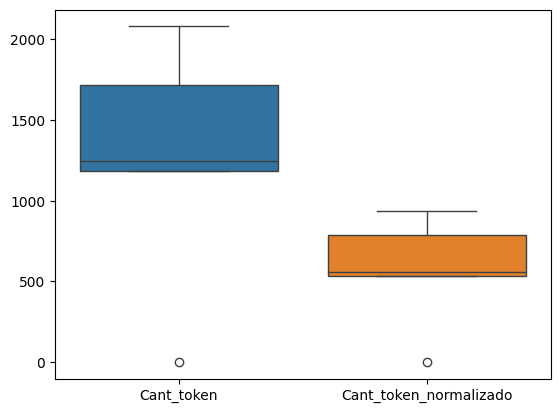

In [32]:
# Distribución
display(texto_limpio_df[['Cant_token','Cant_token_normalizado']].describe().T)
sns.boxplot(data=texto_limpio_df[['Cant_token','Cant_token_normalizado']])


¿texto vacios?

In [33]:
# Error
Error_texto = texto_limpio_df[texto_limpio_df['Cant_token_normalizado']<1].copy()
#Error_texto['texto_proyecto normalizado'] = Error_texto['Título'].apply(limpieza_basica_texto) 

In [34]:
Error_texto.shape

(1, 6)

In [35]:
Error_texto

,Proyecto.ID,texto_proyecto,texto_proyecto procesado,texto_proyecto normalizado,Cant_token,Cant_token_normalizado
0,HCDN266842,\n\n\n,,,0,0


Exploramos por período


In [36]:
with open(RESULTADOS_DIR + 'proyecto_2009_2024_LIMPIO2_df.pkl', 'rb') as file: # textos procesados
    proyecto_2009_2024_df = pickle.load(file)

In [37]:
base_texto_df = pd.merge(texto_limpio_df,proyecto_2009_2024_df[['Proyecto.ID','Proyecto_SALUD','Resultado','Periodo','Año']], how = 'inner',left_on = 'Proyecto.ID', right_on='Proyecto.ID' )

In [39]:
base_texto_df = base_texto_df[base_texto_df['Cant_token_normalizado']>0]

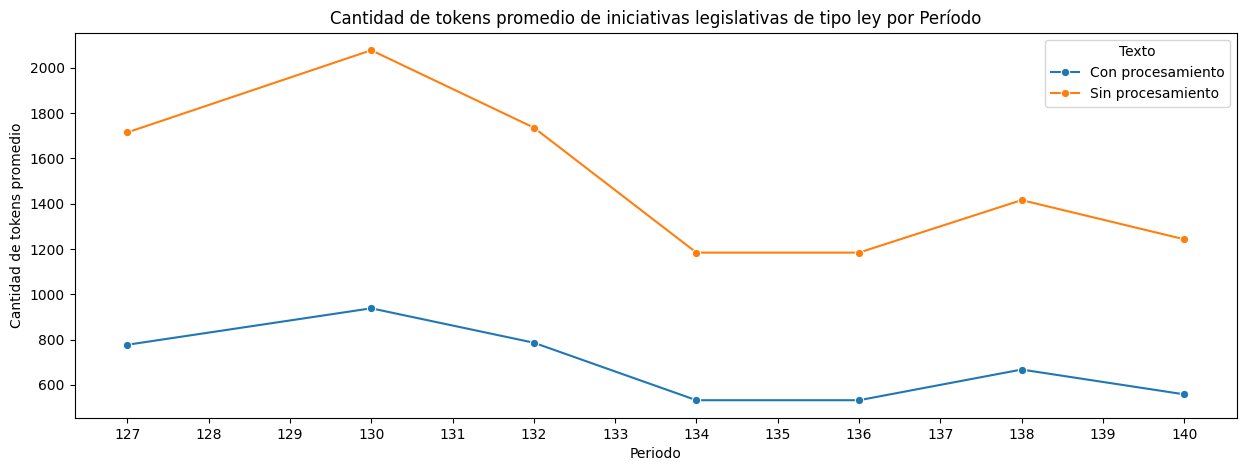

In [43]:
import matplotlib.ticker as ticker
sns.color_palette("pastel")

Temp = pd.pivot_table(base_texto_df, values=['Cant_token','Cant_token_normalizado'], index=['Periodo'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp = pd.melt(Temp, id_vars=['Periodo'], value_vars=['Cant_token_normalizado', 'Cant_token'])
Temp.columns = ['Periodo','Texto','Cantidad de tokens promedio']
Temp["Texto"] = Temp["Texto"].map({'Cant_token': 'Sin procesamiento', 'Cant_token_normalizado': 'Con procesamiento'})

f, ax = plt.subplots(1, 1, figsize=(15, 5), sharey = True)
sns.lineplot(x='Periodo', y='Cantidad de tokens promedio', hue='Texto', data = Temp, estimator='sum', errorbar= None , linestyle='-', ax = ax, marker="o")
legend_handles, _= ax.get_legend_handles_labels()

ax.set_title('Cantidad de tokens promedio de iniciativas legislativas de tipo ley por Período')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo_tokens_muertesubita.png")
plt.show()


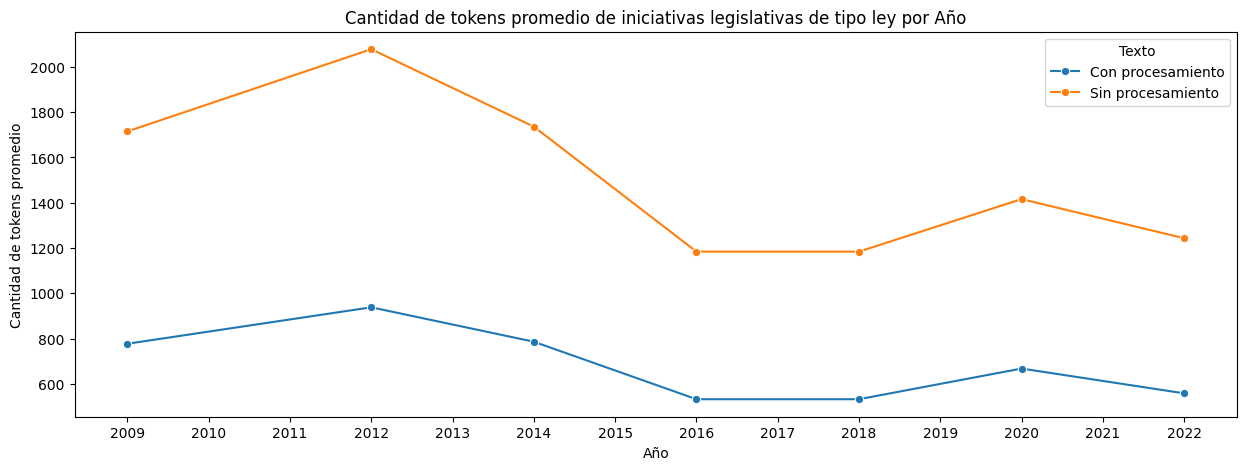

In [42]:

Temp = pd.pivot_table(base_texto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Año'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp = pd.melt(Temp, id_vars=['Año'], value_vars=['Cant_token_normalizado', 'Cant_token'])
Temp.columns = ['Año','Texto','Cantidad de tokens promedio']
Temp["Texto"] = Temp["Texto"].map({'Cant_token': 'Sin procesamiento', 'Cant_token_normalizado': 'Con procesamiento'})

f, ax = plt.subplots(1, 1, figsize=(15, 5), sharey = True)
sns.lineplot(x='Año', y='Cantidad de tokens promedio', hue='Texto', data = Temp, estimator='sum', errorbar= None , linestyle='-', ax = ax, marker="o")
legend_handles, _= ax.get_legend_handles_labels()

ax.set_title('Cantidad de tokens promedio de iniciativas legislativas de tipo ley por Año')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
plt.savefig(BASE_DIR+"imagenes/evolucion_IL_a_tokennos_muertesubita.png")
plt.show()


Exploramos por resultado

In [44]:
pd.pivot_table(pd.merge(texto_limpio_df,proyecto_2009_2024_df[['Proyecto.ID','Proyecto_SALUD','Resultado','Periodo']], how = 'inner',left_on = 'Proyecto.ID', right_on='Proyecto.ID' ), values=['Cant_token','Cant_token_normalizado'], index=['Resultado'],
                       aggfunc={'Cant_token': ('mean','median',"min","max"),'Cant_token_normalizado': ('mean','median',"min","max")}).reset_index()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17172\3371916721.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(pd.merge(texto_limpio_df,proyecto_2009_2024_df[['Proyecto.ID','Proyecto_SALUD','Resultado','Periodo']], how = 'inner',left_on = 'Proyecto.ID', right_on='Proyecto.ID' ), values=['Cant_token','Cant_token_normalizado'], index=['Resultado'],


Resultado Cant_token                       \
                                                    max         mean  median   
0  NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN     2078.0  1330.222222  1243.0   

       Cant_token_normalizado                          
   min                    max        mean median  min  
0  0.0                  938.0  606.444444  558.0  0.0

In [45]:
# https://github.com/RicardoMoya/NLP_with_Python/blob/master/21_Topic_Modeling_noticias.ipynb
# https://github.com/RicardoMoya/NLP_with_Python/blob/master/05_Bag_of_Words_BoW.ipynb

#import gensim
#import gensim.corpora as corpora
from pprint import pprint
#from gensim import corpora
from collections import defaultdict
from collections import Counter

,frecuencia
count,1220.000000
mean,4.473770
std,6.461609
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,77.000000


Text(0.5, 1.0, 'Top 50 palabras más frecuentes')

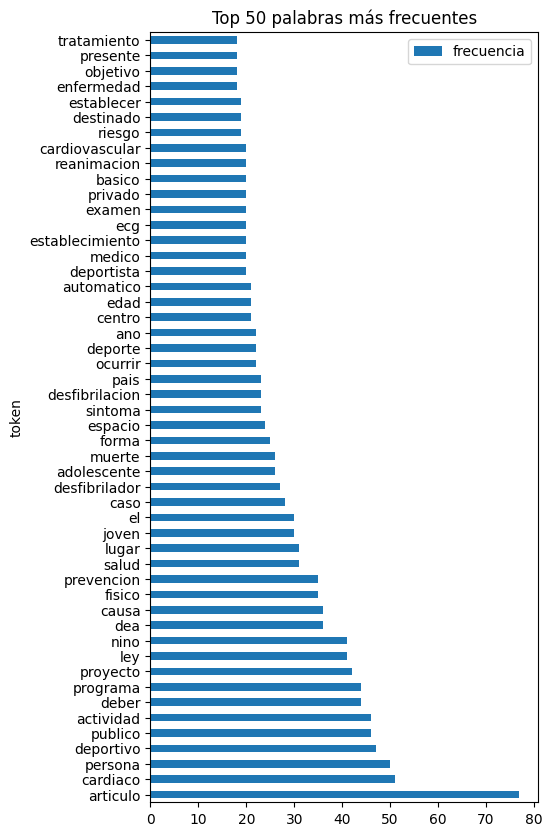

In [46]:
##################################PASOS DICCIONARIO########################
corpus_norm = list(texto_limpio_df['texto_proyecto normalizado'])
# Tokenizamos
documents_tok = [word.split() for word in corpus_norm]

# Creamos el diccionario (vocabulario)
frequency = defaultdict(int)
for doc in documents_tok:
    for token in doc:
        frequency[token] += 1

# Exploramos todas las palabras para limpiar mejor
#counter = Counter(frequency)
frecuencia_df = pd.DataFrame.from_records(list(frequency.items()), columns = ['token','frecuencia'])
display(frecuencia_df.describe())

fig, ax = plt.subplots(figsize=(5, 10))
frecuencia_df.sort_values('frecuencia', ascending=False).head(50).plot(kind='barh', x = 'token', ax=ax)
ax.set_title('Top 50 palabras más frecuentes')


<Axes: >

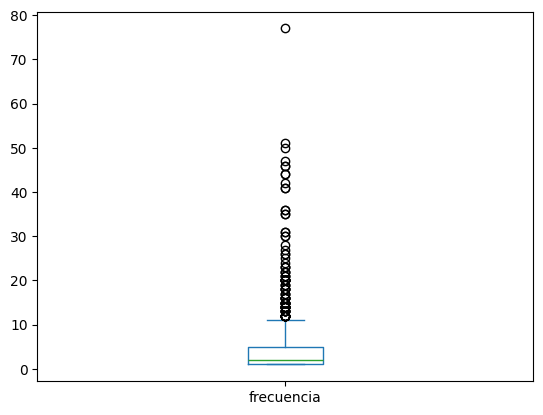

In [47]:
frecuencia_df['frecuencia'].plot(kind='box')

In [48]:
frecuencia_df = frecuencia_df.sort_values('frecuencia', ascending=False)

In [49]:
frecuencia_df.head(50)

,token,frecuencia
19,articulo,77
158,cardiaco,51
236,persona,50
40,deportivo,47
60,publico,46
136,actividad,46
46,deber,44
6,programa,44
0,proyecto,42
1,ley,41


In [50]:
# Calcular Q1, Q3 e IQR
q1 = frecuencia_df['frecuencia'].quantile(0.25)
q3 = frecuencia_df['frecuencia'].quantile(0.75)
iqr = q3 - q1

# Límites para detectar outliers
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Filtrar outliers
outliers = frecuencia_df[(frecuencia_df['frecuencia'] < limite_inferior) | (frecuencia_df['frecuencia'] > limite_superior)]

print(f"IQR: {iqr}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")
print("Outliers encontrados:")
print(outliers)


IQR: 4.0
Límite inferior: -5.0
Límite superior: 11.0
Outliers encontrados:
          token  frecuencia
19     articulo          77
158    cardiaco          51
236     persona          50
40    deportivo          47
60      publico          46
..          ...         ...
553      minuto          12
39   participar          12
269       algun          12
78   aplicacion          12
63       social          12

[95 rows x 2 columns]


In [51]:
import pickle

with open(RESULTADOS_DIR + 'muerte_subita/texto_normalizado_2009_2024_df.pkl', 'wb') as file:
    pickle.dump(texto_limpio_df,file)

In [52]:
texto_limpio_df.shape

(9, 6)

In [54]:
base_texto_df = pd.merge(texto_limpio_df,proyecto_2009_2024_df[['Proyecto.ID','Proyecto_girado_a_comisiones_SALUD','Proyecto_SALUD','Resultado','Max_Orden','Tiene_antecedente_por_titulo_proy','Periodo','Año']], how = 'inner',left_on = 'Proyecto.ID', right_on='Proyecto.ID' )

In [56]:
from tqdm import tqdm

base_texto_df['Tokens'] = base_texto_df['texto_proyecto normalizado'].apply(lambda x: x.split()) #list of lists

In [60]:
base_texto_df = base_texto_df[base_texto_df['Cant_token']>0]

In [61]:
base_texto_df.shape

(8, 14)

In [62]:
base_texto_df[['texto_proyecto normalizado','Tokens']].head(5)


texto_proyecto normalizado  \
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  proyecto ley senado camara diputado creacion programa difusion informacion padre miembro comunidad escolar destinado prevenir  regimen capacitacion reanimacion cardiopulmonar articulo creasar programa difusion informacion padre alumno maestro profesor capacitacion reanimacion cardiovascular basico destinado distinto estamento institucion escolar articulo establecer caract obligatorio chequeo cardiologico ingreso escuela primario ingreso escuela secundario articulo estudiante participar programa deportivo organizado deberar repetir ano articulo control deber incluir examen fisico electrocardiograma ecocardiograma grupo establecido articulo agregar ecg esfuerzo articulo establecimiento medico asistencial publico seguri dad social entidad medicina prepagar deber reconocer incorporar cobertura control articulo invitar provincia ciudad autonoma aires adherir presente proyecto articulo autorida aplicacion serar determinado ejecutivo nacional articulo comuniquese ejecutivo nacional fundamento senor presidente objetivo principal proyecto prevencion  cuyo prevalencia baja nino adolescente origen alteracion cardiovascular congenita estructural electrica detectar cheq ueo cardiologico importante cardiomiopatia hipertrofica causa cardiologica conmotio corai comun denominar muerte ocurrir forma inesperado causa natural traumatico violento corto periodo tiempo hora inicio sintoma nino adolescente frecuente presentar sintoma premonitorio mayoria nino adolescente practicar deporte ambito actividade extraescolar centro educativo actividad ludicar club frecuente iniciacion edad practica deportivo reglado competitivo entrenamiento programado beneficio ejerc icio participacion disciplina deportivo evidente edad promocion actividad fisico importancia aumento obesidad sedentarismo nino adolescente grupo escolar patologia cardiaco desconocido significar alto riesgo ejercicio liberar adrenalina actuar disparador problema card

### Común vocabulario por período

In [63]:
# Guardar - OJO CON LOS REGISTROS SIN PERIODO
pickle.dump(base_texto_df, open(RESULTADOS_DIR +'/muerte_subita/base_texto_df_ley_0924.pkl', 'wb'))

In [64]:
#Agrupar titulos por periodo
periodo_salud_original_df = base_texto_df[base_texto_df['Proyecto_SALUD']==1].groupby('Periodo')['texto_proyecto'].apply(lambda x: ' '.join(x)).reset_index()
periodo_salud_normalizado_df = base_texto_df[base_texto_df['Proyecto_SALUD']==1].groupby('Periodo')['texto_proyecto normalizado'].apply(lambda x: ' '.join(x)).reset_index()


In [65]:
periodo_salud_original_df.head(3)

Periodo  \
0    127.0   
1    130.0   
2    132.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [66]:
def paso_uno_pares(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]

In [67]:
# Ordenar períodos según el número 
periodos = sorted(periodo_salud_original_df['Periodo'].to_list())
periodo_pares = paso_uno_pares(periodos)
print(periodo_pares)

[(127.0, 130.0), (130.0, 132.0), (132.0, 134.0), (134.0, 136.0), (136.0, 138.0), (138.0, 140.0)]


#### Calcular la intersección de vocabulario/token entre pares de períodos

In [68]:
# Sobre titulos sin limpieza
periodo_salud_original_df['vocab'] = periodo_salud_original_df['texto_proyecto'].str.lower()
periodo_salud_original_df['vocab'] = periodo_salud_original_df['vocab'].str.split()
comun_vocab_list = []

for par in periodo_pares:
    
    s1 = set(periodo_salud_original_df.loc[(periodo_salud_original_df.Periodo==par[0])].vocab.values[0])
    s2 = set(periodo_salud_original_df.loc[(periodo_salud_original_df.Periodo==par[1])].vocab.values[0])
    comun_vocab = len(s1.intersection(s2))
    comun_vocab_list.append([par, comun_vocab])
    
comun_vocab_salud_original_df = pd.DataFrame(comun_vocab_list, columns = ['par', 'comun_vocab'])
# comun_vocabab_df_original.to_csv('../out_files/comun_vocabab_df_original.csv', index=False)
print(comun_vocab_salud_original_df.head(2))

              par  comun_vocab
0  (127.0, 130.0)          207
1  (130.0, 132.0)          209


In [69]:
comun_vocab_salud_original_df.to_csv(RESULTADOS_DIR+'muerte_subita/archivos_out/comun_vocab_salud_original_periodoparl.csv', index=False)


In [70]:
periodo_salud_normalizado_df['vocab'] = periodo_salud_normalizado_df['texto_proyecto normalizado'].str.split()
comun_vocab_norm_list = []

for par in periodo_pares:
    
    s1 = set(periodo_salud_normalizado_df.loc[(periodo_salud_normalizado_df.Periodo==par[0])].vocab.values[0])
    s2 = set(periodo_salud_normalizado_df.loc[(periodo_salud_normalizado_df.Periodo==par[1])].vocab.values[0])
    comun_vocab = len(s1.intersection(s2))
    comun_vocab_norm_list.append([par, comun_vocab])
    
comun_vocab_salud_norm_df = pd.DataFrame(comun_vocab_norm_list, columns = ['par', 'comun_vocab'])
# comun_vocabab_df_original.to_csv('../out_files/comun_vocabab_df_original.csv', index=False)
print(comun_vocab_salud_norm_df.head(2))

              par  comun_vocab
0  (127.0, 130.0)          159
1  (130.0, 132.0)          161


In [71]:
comun_vocab_salud_norm_df.to_csv(RESULTADOS_DIR+'muerte_subita/archivos_out/comun_vocab_salud_norm.csv', index=False)


#### Visualizar vocabulario común

In [72]:
periodos = {
    127: (2009, 2010),
    128: (2010, 2011),
    129: (2011, 2012),
    130: (2012, 2013),
    131: (2013, 2014),
    132: (2014, 2015),
    133: (2015, 2016),
    134: (2016, 2017),
    135: (2017, 2018),
    136: (2018, 2019),
    137: (2019, 2020),
    138: (2020, 2021),
    139: (2021, 2022),
    140: (2022, 2023),
    141: (2023, 2024)
}

comun_vocab_salud_original_df['version'] = 'Sin procesamiento'
comun_vocab_salud_original_df['Periodo inicio'] = comun_vocab_salud_original_df['par'].map(lambda x: periodos[x[0]][0])
comun_vocab_salud_original_df['Periodo fin'] = comun_vocab_salud_original_df['par'].map(lambda x: periodos[x[1]][1])
comun_vocab_salud_original_df['Periodo intermedio'] = ((comun_vocab_salud_original_df['Periodo inicio'] 
                                        + comun_vocab_salud_original_df['Periodo fin']) / 2)

comun_vocab_salud_norm_df['version'] = 'Con procesamiento'
comun_vocab_salud_norm_df['Periodo inicio'] = comun_vocab_salud_norm_df['par'].map(lambda x: periodos[x[0]][0])
comun_vocab_salud_norm_df['Periodo fin'] = comun_vocab_salud_norm_df['par'].map(lambda x: periodos[x[1]][1])
comun_vocab_salud_norm_df['Periodo intermedio'] = ((comun_vocab_salud_norm_df['Periodo inicio'] 
                                        + comun_vocab_salud_norm_df['Periodo fin']) / 2)


In [73]:
todas_versiones_df = pd.concat([comun_vocab_salud_original_df,comun_vocab_salud_norm_df], axis=0)

In [74]:
todas_versiones_df.shape

(12, 6)

In [75]:
todas_versiones_df.head()

,par,comun_vocab,version,Periodo inicio,Periodo fin,Periodo intermedio
0,"(127.0, 130.0)",207,Sin procesamiento,2009,2013,2011.0
1,"(130.0, 132.0)",209,Sin procesamiento,2012,2015,2013.5
2,"(132.0, 134.0)",166,Sin procesamiento,2014,2017,2015.5
3,"(134.0, 136.0)",545,Sin procesamiento,2016,2019,2017.5
4,"(136.0, 138.0)",539,Sin procesamiento,2018,2021,2019.5


In [76]:
todas_versiones_df.describe(include='all')

,par,comun_vocab,version,Periodo inicio,Periodo fin,Periodo intermedio
count,12,12.000000,12,12.000000,12.00000,12.000000
unique,6,NaN,2,NaN,NaN,NaN
top,"(127.0, 130.0)",NaN,Sin procesamiento,NaN,NaN,NaN
freq,2,NaN,6,NaN,NaN,NaN
mean,NaN,301.166667,NaN,2014.833333,2018.00000,2016.416667
std,NaN,160.831269,NaN,3.833663,3.56753,3.697870
min,NaN,119.000000,NaN,2009.000000,2013.00000,2011.000000
25%,NaN,164.750000,NaN,2012.000000,2015.00000,2013.500000
50%,NaN,262.500000,NaN,2015.000000,2018.00000,2016.500000
75%,NaN,378.500000,NaN,2018.000000,2021.00000,2019.500000


In [77]:
def periodos_a_fechas(periodos):

    period_dict = {
                  127:'01/03/2009-28/02/2010',
                  128:'01/03/2010-28/02/2011',
                  129:'01/03/2011-29/02/2012',
                  130:'01/03/2012-28/02/2013',
                  131:'01/03/2013-28/02/2014',
                  132:'01/03/2014-28/02/2015',
                  133:'01/03/2015-29/02/2016',
                  134:'01/03/2016-28/02/2017',
                  135:'01/03/2017-28/02/2018',
                  136:'01/03/2018-28/02/2019',
                  137:'01/03/2019-29/02/2020', 
                  138:'01/03/2020-28/02/2021', 
                  139:'01/03/2021-28/02/2022',
                  140:'01/03/2022-28/02/2023',
                  141:'01/03/2023-29/02/2024',
    }
    
    if isinstance(periodos, tuple):
#         return r"$\bf{" + str(periods[0]) + "\ &\ " +str(periods[1]) + "}$" + "\n" +period_dict[periods[0]]+' &\n '+period_dict[periods[1]]
        return f'{str(periodos[0])} ({period_dict[periodos[0]]}) &\n {str(periodos[1])} ({period_dict[periodos[1]]})'

    else:
        return r"$\bf{" + 'Period\ '+ str(periodos)+ "}$"+'\n'+period_dict[periodos]        


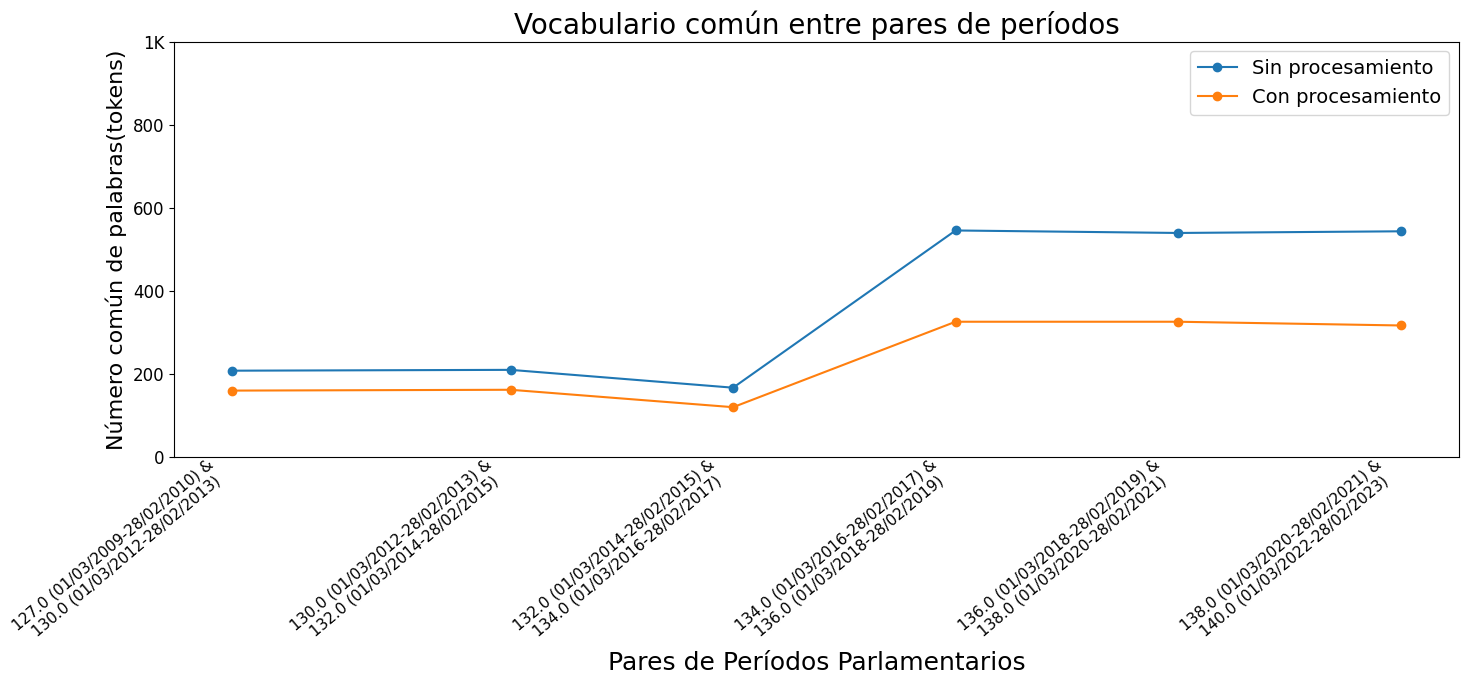

<Figure size 640x480 with 0 Axes>

In [78]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
from numerize import numerize 


fig = plt.figure(figsize=(15, 6))
colors = sns.color_palette("hls", 90) #90 is available pairs

plt.rcParams.update({'font.size': 12})

versions = list(set(todas_versiones_df.version.to_list()))
                
for version in versions:
    
    Y = todas_versiones_df.loc[(todas_versiones_df['version']==version)].comun_vocab.to_list()
    X = todas_versiones_df.loc[(todas_versiones_df['version']==version)]['Periodo intermedio'].to_list()

    plt.plot(X,Y, marker="o")


xticks = comun_vocab_salud_original_df['Periodo intermedio'].unique()
xtick_labels = [ periodos_a_fechas(x) for x in sorted(comun_vocab_salud_original_df['par'].unique()) ]

plt.xlabel('Pares de Períodos Parlamentarios', fontsize=18, labelpad=140)
plt.ylabel('Número común de palabras(tokens)', fontsize=16)

ax = plt.gca()
ax.set_ylim([0,1000])
handles, labels = ax.get_legend_handles_labels()
formatter = FuncFormatter(numerize.numerize)
ax.yaxis.set_major_formatter(formatter)
plt.title('Vocabulario común entre pares de períodos', fontsize=20)
plt.legend(versions, loc='upper right',prop={'size': 14})

for i, xtick in enumerate(xticks):
    plt.annotate(xtick_labels[i], fontsize=11, annotation_clip=False,  rotation=40,  xy=(xtick, -0.5), ma='center', xytext=(xtick-2,-450))
  
    
#hide major xticks
plt.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)

plt.savefig(RESULTADOS_DIR+'muerte_subita/archivos_out/comun_vocab.png')
plt.tight_layout(pad=2)
plt.subplots_adjust(bottom=0.2)
plt.show()
plt.cla()
plt.clf()
fig.clear()

plt.close(fig)


#### Métricas promedio para cada período parlamentario antes del preprocesamiento y después del preprocesamiento

In [79]:
### IL de salud publicadas entres 2010-2023
base_texto_df[base_texto_df['Proyecto_SALUD']==1].shape

(8, 14)

In [80]:
periodo_salud_normalizado_df.shape

(7, 3)

In [81]:
periodo_salud_normalizado_df.columns

Index(['Periodo', 'texto_proyecto normalizado', 'vocab'], dtype='object')

In [82]:
metricas ={ 'Sin procesamiento': {
 'Cantidad promedio de tokens': round(periodo_salud_original_df['vocab'].apply(lambda x : len(x)).sum()/periodo_salud_original_df.shape[0],0),
 'Cantidad promedio de tokens únicos': round(len(set(periodo_salud_original_df.vocab.values[0]))/periodo_salud_original_df.shape[0],0) },
 'Con procesamiento': {
 'Cantidad promedio de tokens': round(periodo_salud_normalizado_df['vocab'].apply(lambda x : len(x)).sum()/periodo_salud_normalizado_df.shape[0],0),
 'Cantidad promedio de tokens únicos': round(len(set(periodo_salud_normalizado_df.vocab.values[0]))/periodo_salud_normalizado_df.shape[0],0)}}
metricas

{'Sin procesamiento': {'Cantidad promedio de tokens': 1710.0,
  'Cantidad promedio de tokens únicos': 114.0},
 'Con procesamiento': {'Cantidad promedio de tokens': 780.0,
  'Cantidad promedio de tokens únicos': 68.0}}

In [83]:
metrica_df = pd.DataFrame.from_dict(metricas, orient= 'index')
metrica_df.to_csv(RESULTADOS_DIR+'muerte_subita/archivos_out/metrica_vocab_salud.csv', index=False)
metrica_df

,Cantidad promedio de tokens,Cantidad promedio de tokens únicos
Sin procesamiento,1710.0,114.0
Con procesamiento,780.0,68.0
